# SPTcl-IRAGN Radial Distributions
Benjamin Floyd

Produces a publication-quality plot showing the distribution of all galaxies and IR-bright AGN in the lines of sight to the SPT clusters

In [29]:
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
from astropy.cosmology import FlatLambdaCDM
from astropy.io import fits
from astropy.table import QTable, vstack
from astropy.visualization import quantity_support
from astropy.wcs import WCS
from scipy.spatial.distance import cdist

quantity_support()

cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

In [30]:
def radial_areas(r : np.ndarray[float, ...], z : float, r500 : u.Quantity | float, center : SkyCoord, mask_name : str) -> u.Quantity:
    # Read in the mask file and the mask file's WCS
    image, header = fits.getdata(mask_name, header=True)
    image_wcs = WCS(header)

    # From the WCS get the pixel scale
    pix_scale = image_wcs.proj_plane_pixel_scales()[0]
    pix_area = image_wcs.proj_plane_pixel_area()

    # Convert our center into pixel units
    center_pix = center.to_pixel(image_wcs)

    # Convert our radius to pixels
    r_pix = r * r500 * cosmo.arcsec_per_kpc_proper(z).to(pix_scale.unit / u.Mpc) / pix_scale
    r_pix = r_pix.value

    # Because we potentially integrate to larger radii than can be fit on the image we will need to increase the size of
    # our mask. To do this, we will pad the mask with a zeros out to the radius we need.
    # Find the width needed to pad the image to include the largest radius inside the image.
    width = ((int(round(np.max(r_pix) - center_pix[1])),
              int(round(np.max(r_pix) - (image.shape[0] - center_pix[1])))),
             (int(round(np.max(r_pix) - center_pix[0])),
              int(round(np.max(r_pix) - (image.shape[1] - center_pix[0])))))

    # Ensure that we are adding a non-negative padding width.
    width = tuple(tuple([i if i >= 0 else 0 for i in axis]) for axis in width)

    large_image = np.pad(image, pad_width=width, mode='constant', constant_values=0)

    # Generate a list of all pixel coordinates in the padded image
    image_coords = np.dstack(np.mgrid[0:large_image.shape[0], 0:large_image.shape[1]]).reshape(-1, 2)

    # The center pixel's coordinate needs to be transformed into the large image system
    center_coord = np.array(center_pix) + np.array([width[1][0], width[0][0]])
    center_coord = center_coord.reshape((1, 2))

    # Compute the distance matrix. The entries are a_ij = sqrt((x_j - cent_x)^2 + (y_i - cent_y)^2)
    image_dists = cdist(image_coords, np.flip(center_coord)).reshape(large_image.shape)

    # select all pixels that are within the annulus
    annulus_area = []
    for j in np.arange(len(r_pix) - 1):
        pix_ring = large_image[np.where((r_pix[j] <= image_dists) & (image_dists < r_pix[j + 1]))]

        # Calculate the area
        annulus_area.append(np.sum(pix_ring) * pix_area)

    return u.Quantity(annulus_area)

In [31]:
sptcl_iragn = QTable.read('Data_Repository/Project_Data/SPT-IRAGN/Output/SPTcl_IRAGN_no-stars.fits')

In [32]:
cluster_info = vstack([cluster[0] for cluster in sptcl_iragn.group_by('SPT_ID').groups])

In [33]:
# Compute all radial areas using the mask images
radial_bins = np.arange(0., 2., 0.5)
radial_bin_centers = radial_bins[:-1] + np.diff(radial_bins) / 2

areas = []
for cluster in cluster_info:
    cluster_z = cluster['REDSHIFT']
    cluster_r500 = cluster['R500']
    cluster_center = SkyCoord(cluster['SZ_RA'], cluster['SZ_DEC'], unit=u.deg)
    cluster_mask = cluster['MASK_NAME']

    area = radial_areas(radial_bins, cluster_z, cluster_r500, cluster_center, cluster_mask)
    areas.append(area)
areas = u.Quantity(areas)
cluster_info['RADIAL_AREA'] = areas

In [34]:
# Split the sample by redshift
median_z = np.median(cluster_info['REDSHIFT'])
hi_z_clusters = sptcl_iragn[sptcl_iragn['REDSHIFT'] >= median_z]
lo_z_clusters = sptcl_iragn[sptcl_iragn['REDSHIFT'] < median_z]

hi_z_cluster_info = cluster_info[cluster_info['REDSHIFT'] >= median_z]
lo_z_cluster_info = cluster_info[cluster_info['REDSHIFT'] < median_z]

In [35]:
# Split the sample by cluster mass
median_mass = np.median(cluster_info['M500'])
hi_mass_clusters = sptcl_iragn[sptcl_iragn['M500'] >= median_mass]
lo_mass_clusters = sptcl_iragn[sptcl_iragn['M500'] < median_mass]

hi_mass_cluster_info = cluster_info[cluster_info['M500'] >= median_mass]
lo_mass_cluster_info = cluster_info[cluster_info['M500'] < median_mass]

In [36]:
# Select for the AGN in the catalog
sptcl_iragn_agn = sptcl_iragn[sptcl_iragn['SELECTION_MEMBERSHIP'] >= 0.5]

hi_z_sptcl_iragn_agn = hi_z_clusters[hi_z_clusters['SELECTION_MEMBERSHIP'] >= 0.5]
lo_z_sptcl_iragn_agn = lo_z_clusters[lo_z_clusters['SELECTION_MEMBERSHIP'] >= 0.5]

hi_mass_sptcl_iragn_agn = hi_mass_clusters[hi_mass_clusters['SELECTION_MEMBERSHIP'] >= 0.5]
lo_mass_sptcl_iragn_agn = lo_mass_clusters[lo_mass_clusters['SELECTION_MEMBERSHIP'] >= 0.5]

In [37]:
# Bin both all galaxies and the AGN samples
all_gals, _ = np.histogram(sptcl_iragn['RADIAL_SEP_R500'], bins=radial_bins)
all_agn, _ = np.histogram(sptcl_iragn_agn['RADIAL_SEP_R500'], bins=radial_bins)

hi_z_gals, _ = np.histogram(hi_z_clusters['RADIAL_SEP_R500'], bins=radial_bins)
hi_z_agn, _ = np.histogram(hi_z_sptcl_iragn_agn['RADIAL_SEP_R500'], bins=radial_bins)

lo_z_gals, _ = np.histogram(lo_z_clusters['RADIAL_SEP_R500'], bins=radial_bins)
lo_z_agn, _ = np.histogram(lo_z_sptcl_iragn_agn['RADIAL_SEP_R500'], bins=radial_bins)

hi_mass_gals, _ = np.histogram(hi_mass_clusters['RADIAL_SEP_R500'], bins=radial_bins)
hi_mass_agn, _ = np.histogram(hi_mass_sptcl_iragn_agn['RADIAL_SEP_R500'], bins=radial_bins)

lo_mass_gals, _ = np.histogram(lo_mass_clusters['RADIAL_SEP_R500'], bins=radial_bins)
lo_mass_agn, _ = np.histogram(lo_mass_sptcl_iragn_agn['RADIAL_SEP_R500'], bins=radial_bins)

In [38]:
stacked_areas = np.sum(u.Quantity(cluster_info['RADIAL_AREA']), axis=0)

hi_z_stacked_areas = np.sum(u.Quantity(hi_z_cluster_info['RADIAL_AREA']), axis=0)
lo_z_stacked_areas = np.sum(u.Quantity(lo_z_cluster_info['RADIAL_AREA']), axis=0)

hi_mass_stacked_areas = np.sum(u.Quantity(hi_mass_cluster_info['RADIAL_AREA']), axis=0)
lo_mass_stacked_areas = np.sum(u.Quantity(lo_mass_cluster_info['RADIAL_AREA']), axis=0)

In [39]:
# Convert to densities
all_gal_dens = all_gals / stacked_areas.to(u.arcmin**2)
all_agn_dens = all_agn / stacked_areas.to(u.arcmin**2)

hi_z_gal_dens = hi_z_gals / hi_z_stacked_areas.to(u.arcmin**2)
hi_z_agn_dens = hi_z_agn / hi_z_stacked_areas.to(u.arcmin**2)

lo_z_gal_dens = lo_z_gals / lo_z_stacked_areas.to(u.arcmin**2)
lo_z_agn_dens = lo_z_agn / lo_z_stacked_areas.to(u.arcmin**2)

hi_mass_gal_dens = hi_mass_gals / hi_mass_stacked_areas.to(u.arcmin**2)
hi_mass_agn_dens = hi_mass_agn / hi_mass_stacked_areas.to(u.arcmin**2)

lo_mass_gal_dens = lo_mass_gals / lo_mass_stacked_areas.to(u.arcmin**2)
lo_mass_agn_dens = lo_mass_agn / lo_mass_stacked_areas.to(u.arcmin**2)

In [40]:
frac_agn_den = all_agn_dens.to(u.deg**-2) / all_gals

hi_z_frac_agn_den = hi_z_agn_dens.to(u.deg**-2) / hi_z_gals
lo_z_frac_agn_den = lo_z_agn_dens.to(u.deg**-2) / lo_z_gals

hi_mass_frac_agn_den = hi_mass_agn_dens.to(u.deg**-2) / hi_mass_gals
lo_mass_frac_agn_den = lo_mass_agn_dens.to(u.deg**-2) / lo_mass_gals

In [41]:
frac_agn = all_agn / all_gals

hi_z_frac_agn = hi_z_agn / hi_z_gals
lo_z_frac_agn = lo_z_agn / lo_z_gals

hi_mass_frac_agn = hi_mass_agn / hi_mass_gals
lo_mass_frac_agn = lo_mass_agn / lo_mass_gals

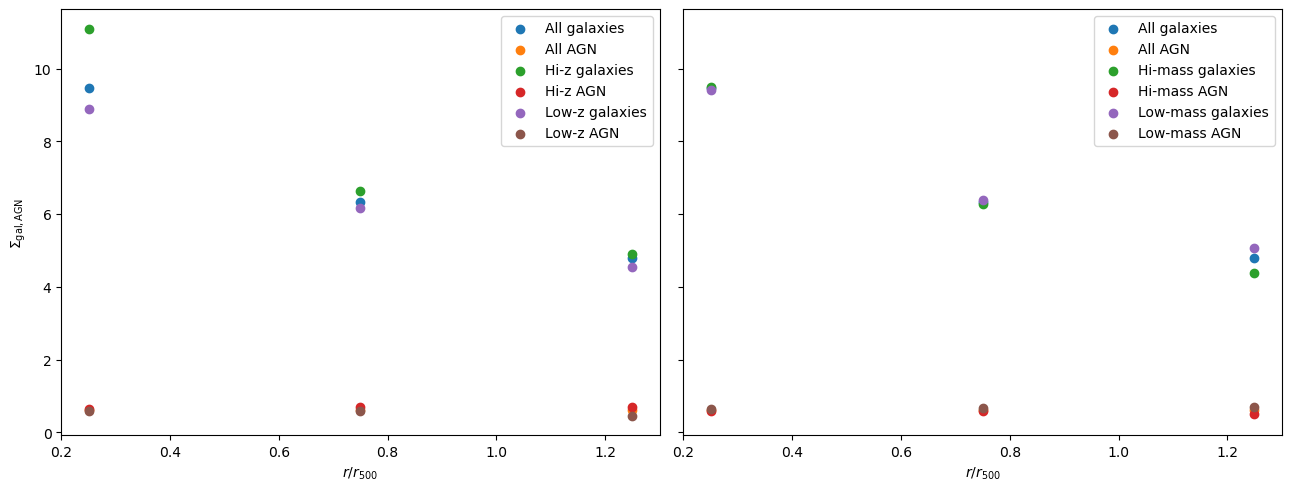

In [42]:
fig, (ax, bx) = plt.subplots(ncols=2, sharey=True, figsize=(2*6.4, 4.8), constrained_layout=True)
ax.scatter(radial_bin_centers, all_gal_dens, label='All galaxies')
ax.scatter(radial_bin_centers, all_agn_dens, label='All AGN')
ax.scatter(radial_bin_centers, hi_z_gal_dens, label='Hi-z galaxies')
ax.scatter(radial_bin_centers, hi_z_agn_dens, label='Hi-z AGN')
ax.scatter(radial_bin_centers, lo_z_gal_dens, label='Low-z galaxies')
ax.scatter(radial_bin_centers, lo_z_agn_dens, label='Low-z AGN')
ax.legend()

bx.scatter(radial_bin_centers, all_gal_dens, label='All galaxies')
bx.scatter(radial_bin_centers, all_agn_dens, label='All AGN')
bx.scatter(radial_bin_centers, hi_mass_gal_dens, label='Hi-mass galaxies')
bx.scatter(radial_bin_centers, hi_mass_agn_dens, label='Hi-mass AGN')
bx.scatter(radial_bin_centers, lo_mass_gal_dens, label='Low-mass galaxies')
bx.scatter(radial_bin_centers, lo_mass_agn_dens, label='Low-mass AGN')
bx.legend()

ax.set(xlabel=r'$r/r_{500}$', ylabel=r'$\Sigma_\mathrm{gal,AGN}$')
bx.set(xlabel=r'$r/r_{500}$')

# fig.savefig('Data_Repository/Project_Data/SPT-IRAGN/Misc_Plots/radial_trends/radial_surface_densities.pdf')
plt.show()

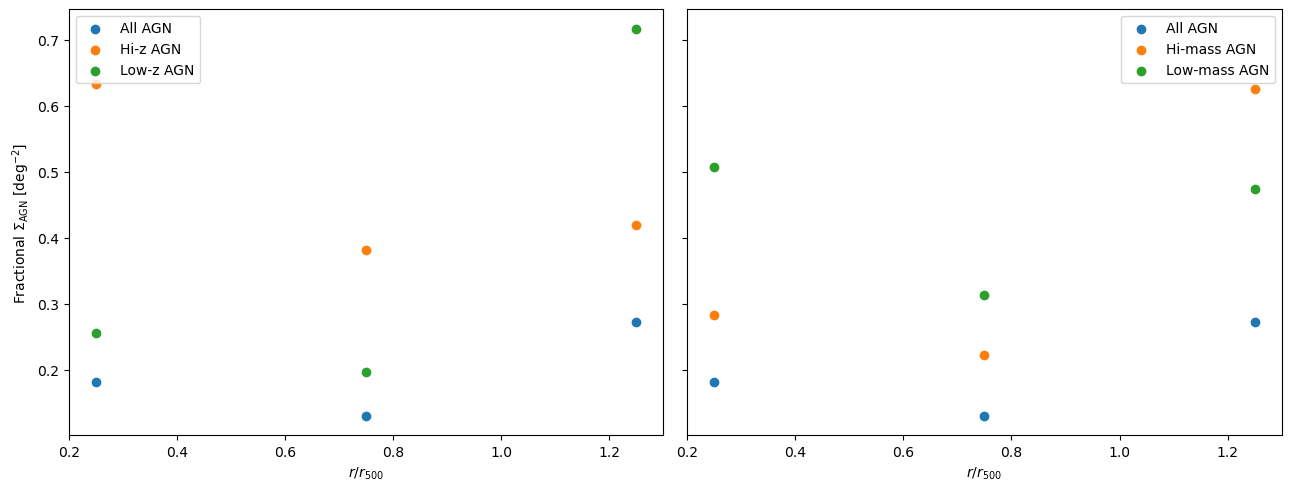

In [43]:
fig, (ax, bx) = plt.subplots(ncols=2, sharey=True, figsize=(2*6.4, 4.8), constrained_layout=True)
ax.scatter(radial_bin_centers, frac_agn_den, label='All AGN')
ax.scatter(radial_bin_centers, hi_z_frac_agn_den, label='Hi-z AGN')
ax.scatter(radial_bin_centers, lo_z_frac_agn_den, label='Low-z AGN')
ax.legend()

bx.scatter(radial_bin_centers, frac_agn_den, label='All AGN')
bx.scatter(radial_bin_centers, hi_mass_frac_agn_den, label='Hi-mass AGN')
bx.scatter(radial_bin_centers, lo_mass_frac_agn_den, label='Low-mass AGN')
bx.legend()

ax.set(xlabel=r'$r/r_{500}$', ylabel=r'Fractional $\Sigma_\mathrm{AGN}$ [deg$^{-2}$]')
bx.set(xlabel=r'$r/r_{500}$')

fig.savefig('Data_Repository/Project_Data/SPT-IRAGN/Misc_Plots/radial_trends/radial_fractional_surface_densities.pdf')
plt.show()

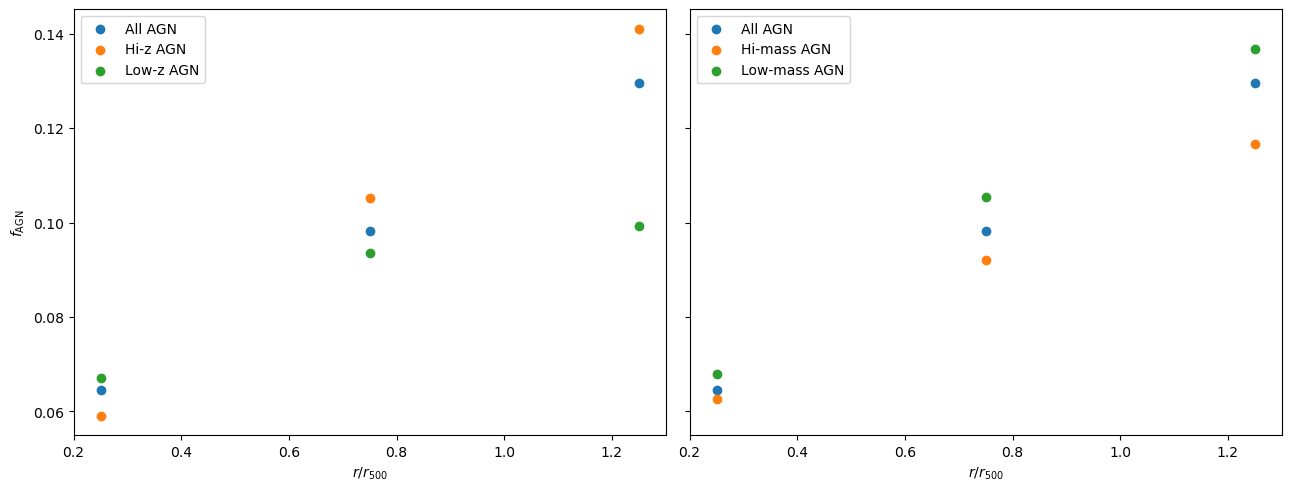

In [44]:
fig, (ax, bx) = plt.subplots(ncols=2, sharey=True, figsize=(2*6.4, 4.8), constrained_layout=True)
ax.scatter(radial_bin_centers, frac_agn, label='All AGN')
ax.scatter(radial_bin_centers, hi_z_frac_agn, label='Hi-z AGN')
ax.scatter(radial_bin_centers, lo_z_frac_agn, label='Low-z AGN')
ax.legend()

bx.scatter(radial_bin_centers, frac_agn, label='All AGN')
bx.scatter(radial_bin_centers, hi_mass_frac_agn, label='Hi-mass AGN')
bx.scatter(radial_bin_centers, lo_mass_frac_agn, label='Low-mass AGN')
bx.legend()

ax.set(xlabel=r'$r/r_{500}$', ylabel=r'$f_\mathrm{AGN}$')
bx.set(xlabel=r'$r/r_{500}$')

fig.savefig('Data_Repository/Project_Data/SPT-IRAGN/Misc_Plots/radial_trends/radial_fractional_counts.pdf')
plt.show()